In [1]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("tested.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


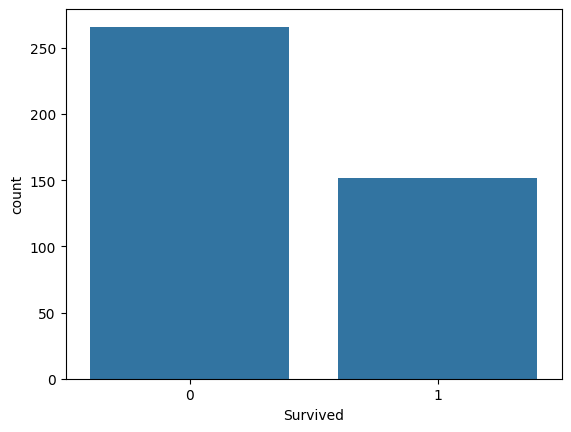

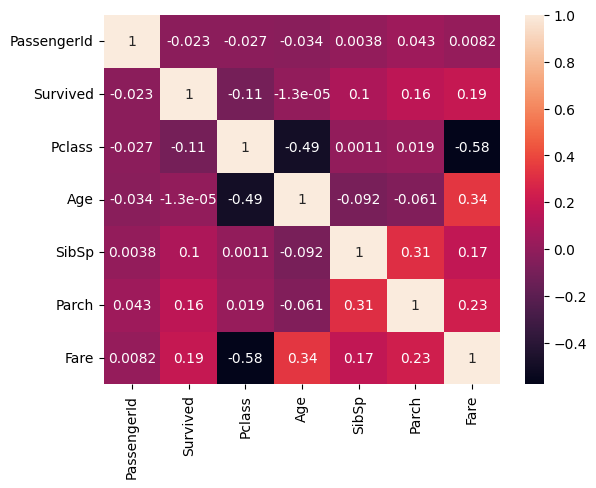

In [7]:
sns.countplot(x='Survived', data=df)
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [32]:
print(df.head())

   PassengerId  Pclass   Age  SibSp  Parch     Fare  \
0          892       3  34.5      0      0   7.8292   
1          893       3  47.0      1      0   7.0000   
2          894       2  62.0      0      0   9.6875   
3          895       3  27.0      0      0   8.6625   
4          896       3  22.0      1      1  12.2875   

   Name_Abelseth, Miss. Karen Marie  Name_Abelseth, Mr. Olaus Jorgensen  \
0                             False                               False   
1                             False                               False   
2                             False                               False   
3                             False                               False   
4                             False                               False   

   Name_Abrahamsson, Mr. Abraham August Johannes  \
0                                          False   
1                                          False   
2                                          False   
3         

In [24]:
print(df.columns)

Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'Name_Abelseth, Miss. Karen Marie',
       'Name_Abelseth, Mr. Olaus Jorgensen',
       'Name_Abrahamsson, Mr. Abraham August Johannes',
       'Name_Abrahim, Mrs. Joseph (Sophie Halaut Easu)',
       ...
       'Cabin_F', 'Cabin_F E46', 'Cabin_F E57', 'Cabin_F G63', 'Cabin_F2',
       'Cabin_F33', 'Cabin_F4', 'Cabin_G6', 'Embarked_Q', 'Embarked_S'],
      dtype='str', length=863)


In [25]:
'Embarked' in df.columns

False

In [28]:
df = pd.get_dummies(df, drop_first=True)

In [31]:
print(df.columns)

Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'Name_Abelseth, Miss. Karen Marie',
       'Name_Abelseth, Mr. Olaus Jorgensen',
       'Name_Abrahamsson, Mr. Abraham August Johannes',
       'Name_Abrahim, Mrs. Joseph (Sophie Halaut Easu)',
       ...
       'Cabin_F', 'Cabin_F E46', 'Cabin_F E57', 'Cabin_F G63', 'Cabin_F2',
       'Cabin_F33', 'Cabin_F4', 'Cabin_G6', 'Embarked_Q', 'Embarked_S'],
      dtype='str', length=863)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
# Fill numeric columns
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)



C:\Users\asadu\AppData\Local\Temp\ipykernel_11288\811125960.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\asadu\AppData\Local\Temp\ipykernel_11288\811125960.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment

0        7.8292
1        7.0000
2        9.6875
3        8.6625
4       12.2875
         ...   
413      8.0500
414    108.9000
415      7.2500
416      8.0500
417     22.3583
Name: Fare, Length: 418, dtype: float64

In [40]:
df.dropna(inplace=True)

In [44]:
import numpy as np

# Total number of NaNs in X_train
print(np.isnan(X_train).sum())

73


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [56]:
import numpy as np

# If X is still a DataFrame
print(X.isnull().sum().sort_values(ascending=False))  

# If X is already a NumPy array
print(np.isnan(X).sum())  # total NaNs
print(np.where(np.isnan(X)))  # exact row/column of NaNs

Age            86
Fare            1
PassengerId     0
SibSp           0
Pclass          0
Parch           0
Sex_male        0
Embarked_Q      0
Embarked_S      0
dtype: int64
PassengerId     0
Pclass          0
Age            86
SibSp           0
Parch           0
Fare            1
Sex_male        0
Embarked_Q      0
Embarked_S      0
dtype: int64
(array([ 10,  22,  29,  33,  36,  39,  41,  47,  54,  58,  65,  76,  83,
        84,  85,  88,  91,  93, 102, 107, 108, 111, 116, 121, 124, 127,
       132, 133, 146, 148, 151, 152, 160, 163, 168, 170, 173, 183, 188,
       191, 199, 200, 205, 211, 216, 219, 225, 227, 233, 243, 244, 249,
       255, 256, 265, 266, 267, 268, 271, 273, 274, 282, 286, 288, 289,
       290, 292, 297, 301, 304, 312, 332, 339, 342, 344, 357, 358, 365,
       366, 380, 382, 384, 408, 410, 413, 416, 417]), array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 5, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2

In [58]:
# Fill Age and Fare missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)

C:\Users\asadu\AppData\Local\Temp\ipykernel_11288\765130854.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\asadu\AppData\Local\Temp\ipykernel_11288\765130854.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment

0        7.8292
1        7.0000
2        9.6875
3        8.6625
4       12.2875
         ...   
413      8.0500
414    108.9000
415      7.2500
416      8.0500
417     22.3583
Name: Fare, Length: 418, dtype: float64

In [57]:
import numpy as np

# If X is still a DataFrame
print(X.isnull().sum().sort_values(ascending=False))  

# If X is already a NumPy array
print(np.isnan(X).sum())  # total NaNs
print(np.where(np.isnan(X)))  # exact row/column of NaNs

Age            86
Fare            1
PassengerId     0
SibSp           0
Pclass          0
Parch           0
Sex_male        0
Embarked_Q      0
Embarked_S      0
dtype: int64
PassengerId     0
Pclass          0
Age            86
SibSp           0
Parch           0
Fare            1
Sex_male        0
Embarked_Q      0
Embarked_S      0
dtype: int64
(array([ 10,  22,  29,  33,  36,  39,  41,  47,  54,  58,  65,  76,  83,
        84,  85,  88,  91,  93, 102, 107, 108, 111, 116, 121, 124, 127,
       132, 133, 146, 148, 151, 152, 160, 163, 168, 170, 173, 183, 188,
       191, 199, 200, 205, 211, 216, 219, 225, 227, 233, 243, 244, 249,
       255, 256, 265, 266, 267, 268, 271, 273, 274, 282, 286, 288, 289,
       290, 292, 297, 301, 304, 312, 332, 339, 342, 344, 357, 358, 365,
       366, 380, 382, 384, 408, 410, 413, 416, 417]), array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 5, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2

In [59]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [63]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values